Found POI: baoding\保定数据\POI_保定.shp
Found restaurant: baoding\保定数据\大众点评餐馆_保定.shp
Found road graph: outputs_pipeline_aligned\00_graph\baoding_aligned.graphml

general_poi loaded
Path: baoding\保定数据\POI_保定.shp
Rows: 14,338
CRS: EPSG:4326
Bounds: {'minx': 113.79220100027601, 'miny': 38.252046000022915, 'maxx': 116.29728100021805, 'maxy': 39.90832500029859}
Columns: ['address', 'adname', 'page_publi', 'adcode', 'pname', 'cityname', 'name', 'location', '_id', 'type', 'Field11', 'Lon', 'Lat', 'lon2', 'geometry']

restaurant loaded
Path: baoding\保定数据\大众点评餐馆_保定.shp
Rows: 44,606
CRS: EPSG:4326
Bounds: {'minx': 113.84238599971422, 'miny': 38.249259495629246, 'maxx': 116.28291144190962, 'maxy': 39.84780900018524}
Columns: ['id', 'year', 'cityname', 'pname', 'area', 'lng', 'lat', 'geometry']

Road graph loaded
Path: outputs_pipeline_aligned\00_graph\baoding_aligned.graphml
Nodes: 50,419
Edges: 137,694
Edge rows: 137,694
CRS: EPSG:32650
Bounds: {'minx': 358470.91731994867, 'miny': 4295503.3815561775,

,transform,n_points_after_bbox,n_points_scored,mean_dist_to_road_m,median_dist_to_road_m,p75_dist_to_road_m,p90_dist_to_road_m,p95_dist_to_road_m,p99_dist_to_road_m,share_within_10m,share_within_20m,share_within_30m,share_within_50m,share_within_80m,share_within_120m,median_dx_point_to_road_m,median_dy_point_to_road_m
0,gcj02_to_wgs84,3654,3654,27.795194,9.199730,15.777044,25.940087,45.838434,753.432003,0.543240,0.837712,0.919814,0.953202,0.967433,0.973727,0.014383,-0.000977
1,bd09_to_gcj02,3643,3643,37.791027,12.979190,28.758153,64.723670,108.273538,678.477599,0.418337,0.642877,0.761186,0.864672,0.919572,0.955531,0.029411,-0.002549
2,base_declared_epsg4326,3659,3659,37.368481,13.368821,30.150115,68.279688,110.449466,654.202277,0.412681,0.638153,0.749385,0.857065,0.919377,0.955179,0.037253,0.005773
3,wgs84_to_gcj02,3669,3669,40.510500,13.698034,32.513441,75.994672,133.257493,652.188810,0.389752,0.614336,0.729081,0.843554,0.905151,0.943854,0.068226,-0.005048
4,gcj02_to_bd09,3683,3683,45.778345,14.419649,34.225169,88.397636,146.847688,820.936956,0.389085,0.601412,0.721151,0.824056,0.890578,0.935922,-0.004051,-0.059098
5,bd09_to_wgs84,3624,3624,41.150812,14.657161,33.915256,73.871657,127.473167,626.136609,0.374724,0.607892,0.723234,0.840784,0.907285,0.948951,0.027846,0.119723



Best transform: gcj02_to_wgs84
Best median distance: 9.20 m
Median improvement vs base: 4.17 m


Restaurant geometry distance to road, control only:
  rows after bbox: 17,659
  median: 11.85 m
  p90: 24.10 m
  share within 30m: 0.937

Drawing diagnostic figure...
Saved figure: outputs_poi_road_crs_diagnosis\poi_transform_road_diagnosis.png


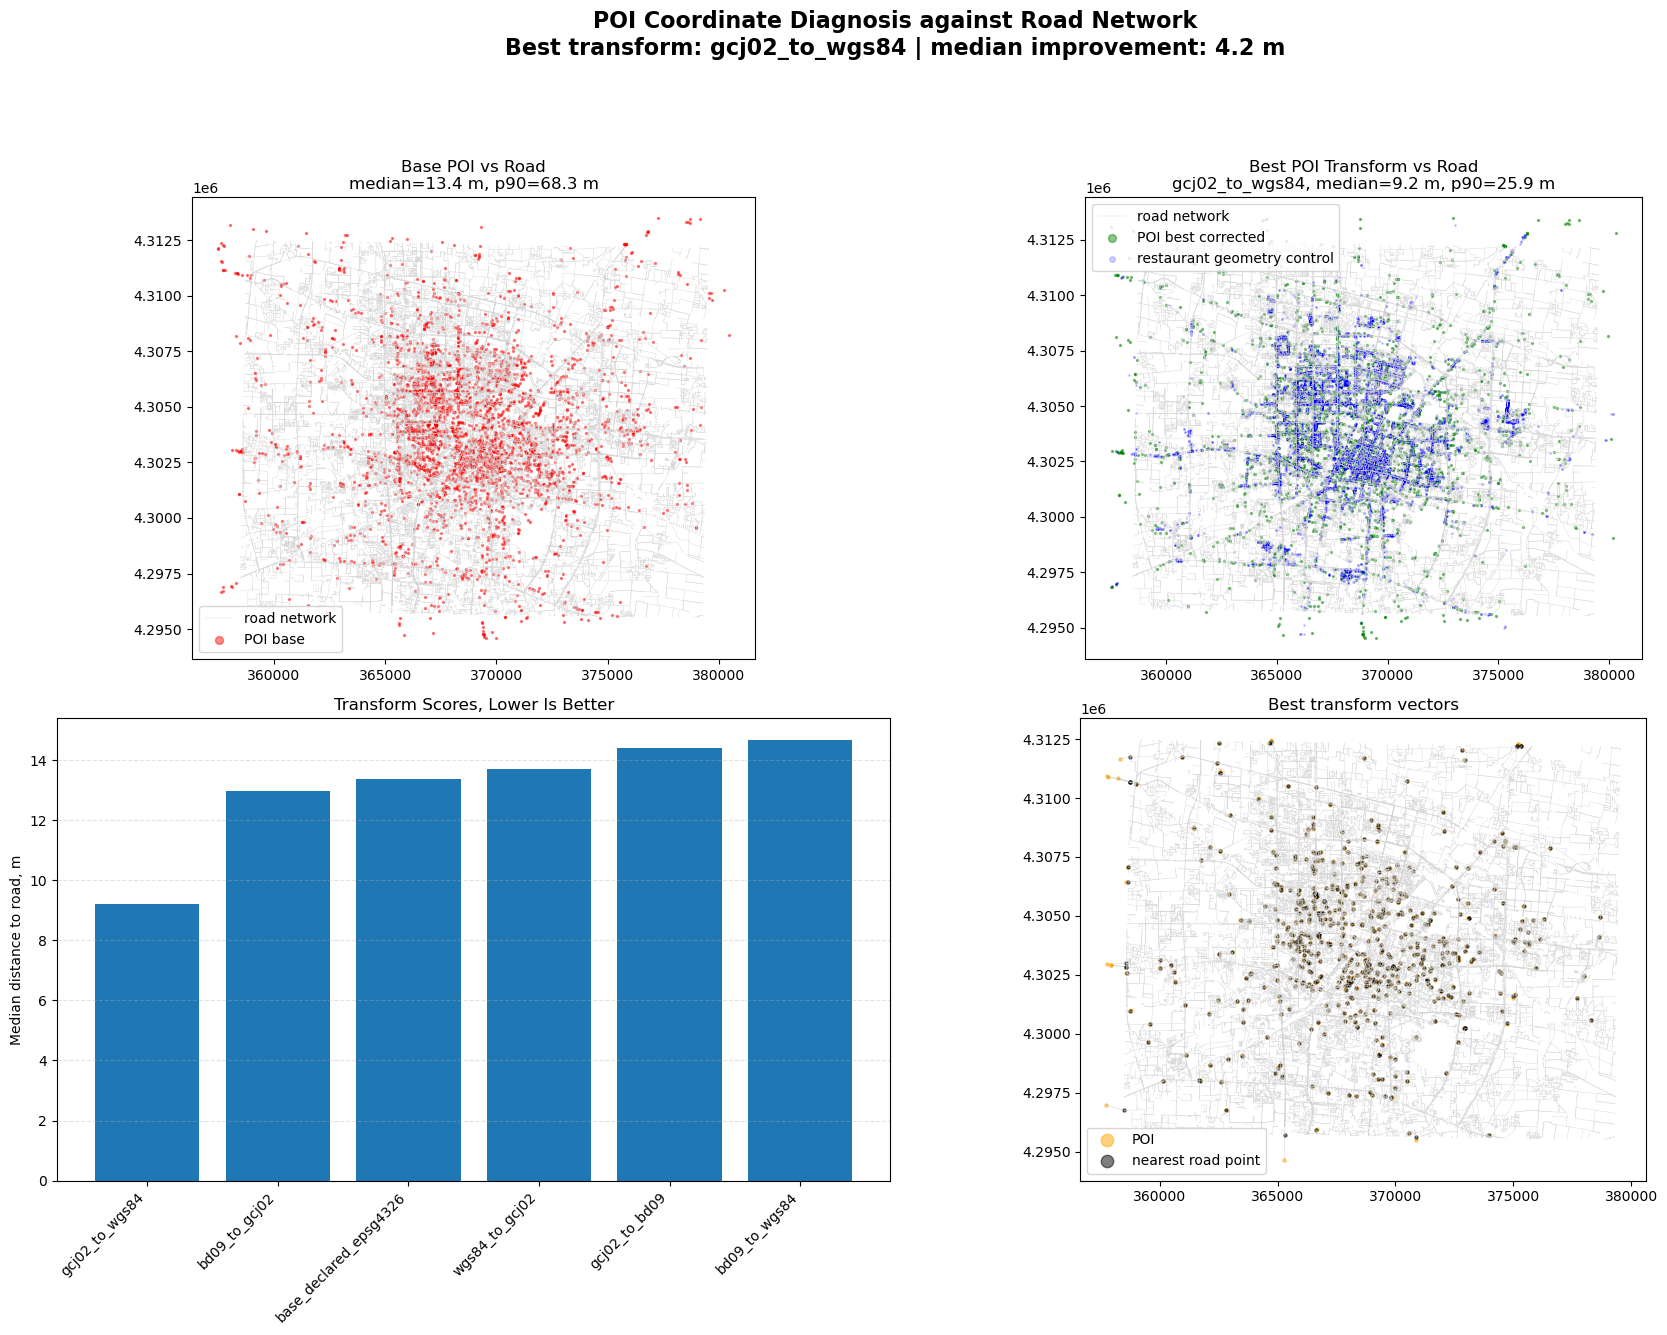


Recommended next step
Best transform: gcj02_to_wgs84
Corrected POI GPKG: outputs_poi_road_crs_diagnosis\POI_保定_corrected_to_road.gpkg

If the diagnostic map confirms improved alignment, use this in 02_build_variables:

POI_INPUT = Path(r'outputs_poi_road_crs_diagnosis\POI_保定_corrected_to_road.gpkg')
FORCE_REBUILD_LANDUSE_FEATURES = True

Keep REST_INPUT unchanged unless restaurant also fails the road-distance control.


In [4]:
# =========================================================
# POI coordinate-system diagnosis against road network
# Test whether POI_保定.shp is GCJ-02 / BD-09 shifted
# Output corrected POI layer for 02_build_variables
# Python 3.8 compatible
# =========================================================

import os
import re
import json
import math
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt

from shapely import wkt
from shapely.geometry import Point, LineString, box
from shapely.ops import nearest_points


# =========================================================
# 0. Config
# =========================================================

# In local notebook, change these to your real paths.
POI_SOURCE = Path(r"/mnt/data/POI_保定.zip")
RESTAURANT_SOURCE = Path(r"/mnt/data/大众点评餐馆_保定.zip")

# Your aligned road graph. This is the key reference layer.
GRAPH_FILE = Path(r"./outputs_pipeline_aligned/00_graph/baoding_aligned.graphml")

# Fallback candidates for local project.
POI_CANDIDATES = [
    POI_SOURCE,
    Path(r"./baoding/保定数据/POI_保定.shp"),
    Path(r"./dataset/baoding/保定数据/POI_保定.shp"),
    Path(r"./POI_保定.shp"),
]
RESTAURANT_CANDIDATES = [
    RESTAURANT_SOURCE,
    Path(r"./baoding/保定数据/大众点评餐馆_保定.shp"),
    Path(r"./dataset/baoding/保定数据/大众点评餐馆_保定.shp"),
    Path(r"./大众点评餐馆_保定.shp"),
]
GRAPH_CANDIDATES = [
    GRAPH_FILE,
    Path(r"./outputs_pipeline_aligned/00_graph/baoding_aligned.graphml"),
    Path(r"./baoding_aligned.graphml"),
    Path(r"./baoding_clear.graphml"),
]

OUT_DIR = Path("./outputs_poi_road_crs_diagnosis")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_SCORE_CSV = OUT_DIR / "poi_transform_road_distance_scores.csv"
OUT_POINT_SAMPLE_CSV = OUT_DIR / "poi_nearest_road_sample.csv"
OUT_DIAG_JSON = OUT_DIR / "poi_transform_road_diagnostics.json"
OUT_FIG = OUT_DIR / "poi_transform_road_diagnosis.png"

OUT_POI_CORRECTED_GPKG = OUT_DIR / "POI_保定_corrected_to_road.gpkg"
OUT_POI_CORRECTED_SHP = OUT_DIR / "POI_保定_corrected_to_road.shp"

WRITE_CORRECTED_SHP = True

# Road-distance diagnostics.
MAX_POINTS_FOR_DISTANCE = 50000
MAX_RESTAURANT_POINTS_FOR_PLOT = 30000
PLOT_SAMPLE_N = 25000
VECTOR_SAMPLE_N = 600
RANDOM_SEED = 42

# Distance thresholds in meters.
ROAD_DISTANCE_THRESHOLDS_M = [10, 20, 30, 50, 80, 120]

# Pick best transform by this metric.
BEST_SCORE_COL = "median_dist_to_road_m"

# If the best transform improves by less than this, do not blindly correct.
MIN_MEDIAN_IMPROVEMENT_M = 15.0

DPI = 180


# =========================================================
# 1. Small helpers
# =========================================================

def find_first_existing(candidates, label):
    checked = []
    for p in candidates:
        p = Path(p)
        checked.append(str(p))
        if p.exists():
            print("Found %s: %s" % (label, p))
            return p
    raise FileNotFoundError("Cannot find %s. Checked: %s" % (label, checked))


def safe_write_csv(df, path, index=False):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    df.to_csv(tmp, index=index)
    os.replace(str(tmp), str(path))


def safe_write_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2, default=str)
    os.replace(str(tmp), str(path))


def unzip_if_needed(path, out_subdir):
    path = Path(path)
    if path.suffix.lower() != ".zip":
        return path

    out_dir = OUT_DIR / out_subdir
    out_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(path, "r") as zf:
        zf.extractall(out_dir)

    shp_files = list(out_dir.rglob("*.shp"))
    if len(shp_files) == 0:
        raise FileNotFoundError("No .shp found inside zip: %s" % path)

    if len(shp_files) > 1:
        print("Multiple shapefiles found in zip. Using first:")
        for p in shp_files:
            print("  ", p)

    return shp_files[0]


def geom_bounds_dict(gdf):
    b = gdf.total_bounds
    return {
        "minx": float(b[0]),
        "miny": float(b[1]),
        "maxx": float(b[2]),
        "maxy": float(b[3]),
    }


def ensure_lonlat_crs(gdf, label):
    out = gdf.copy()

    if out.crs is None:
        b = out.total_bounds
        looks_lonlat = (
            -180 <= b[0] <= 180
            and -180 <= b[2] <= 180
            and -90 <= b[1] <= 90
            and -90 <= b[3] <= 90
        )
        if looks_lonlat:
            print("%s CRS missing. Bounds look like lon/lat, assigning EPSG:4326." % label)
            out = out.set_crs("EPSG:4326")
        else:
            raise ValueError("%s has missing CRS and non-lonlat bounds: %s" % (label, b))

    return out


def load_point_layer(path, label):
    path = unzip_if_needed(path, label)
    gdf = gpd.read_file(path)
    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()

    # Use representative point in case geometry is not Point.
    gdf["geometry"] = gdf.geometry.representative_point()
    gdf = gpd.GeoDataFrame(gdf, geometry="geometry", crs=gdf.crs)
    gdf = ensure_lonlat_crs(gdf, label)

    print("\n%s loaded" % label)
    print("Path:", path)
    print("Rows:", f"{len(gdf):,}")
    print("CRS:", gdf.crs)
    print("Bounds:", geom_bounds_dict(gdf))
    print("Columns:", list(gdf.columns))

    return gdf, path


def read_graph_edges_graphml(graph_path):
    G = nx.read_graphml(str(graph_path))
    graph_crs = G.graph.get("crs", "EPSG:32650")

    node_xy = {}
    for n, d in G.nodes(data=True):
        try:
            node_xy[str(n)] = (float(d["x"]), float(d["y"]))
        except Exception:
            pass

    rows = []
    iterator = G.edges(keys=True, data=True) if G.is_multigraph() else ((u, v, 0, d) for u, v, d in G.edges(data=True))

    for u, v, k, d in iterator:
        geom = d.get("geometry", None)

        if isinstance(geom, str) and len(geom.strip()) > 0:
            try:
                geom = wkt.loads(geom)
            except Exception:
                geom = None

        if geom is None:
            pu = node_xy.get(str(u))
            pv = node_xy.get(str(v))
            if pu is None or pv is None:
                continue
            geom = LineString([pu, pv])

        if geom is None or geom.is_empty:
            continue

        try:
            length = float(d.get("length", geom.length))
        except Exception:
            length = float(geom.length)

        rows.append({
            "u": str(u),
            "v": str(v),
            "key": str(k),
            "length_m": length,
            "geometry": geom,
        })

    edges = gpd.GeoDataFrame(rows, geometry="geometry", crs=graph_crs)

    print("\nRoad graph loaded")
    print("Path:", graph_path)
    print("Nodes:", f"{G.number_of_nodes():,}")
    print("Edges:", f"{G.number_of_edges():,}")
    print("Edge rows:", f"{len(edges):,}")
    print("CRS:", edges.crs)
    print("Bounds:", geom_bounds_dict(edges))

    return edges


# =========================================================
# 2. China coordinate conversion helpers
# =========================================================

# These functions are used only for coordinate diagnosis.
# If POI is GCJ-02 while road graph is WGS84 or OSM-derived, gcj02_to_wgs84 should improve road alignment.

PI = math.pi
A = 6378245.0
EE = 0.00669342162296594323
X_PI = PI * 3000.0 / 180.0


def out_of_china(lng, lat):
    return not (73.66 < lng < 135.05 and 3.86 < lat < 53.55)


def transform_lat(lng, lat):
    ret = -100.0 + 2.0 * lng + 3.0 * lat + 0.2 * lat * lat + 0.1 * lng * lat + 0.2 * math.sqrt(abs(lng))
    ret += (20.0 * math.sin(6.0 * lng * PI) + 20.0 * math.sin(2.0 * lng * PI)) * 2.0 / 3.0
    ret += (20.0 * math.sin(lat * PI) + 40.0 * math.sin(lat / 3.0 * PI)) * 2.0 / 3.0
    ret += (160.0 * math.sin(lat / 12.0 * PI) + 320.0 * math.sin(lat * PI / 30.0)) * 2.0 / 3.0
    return ret


def transform_lng(lng, lat):
    ret = 300.0 + lng + 2.0 * lat + 0.1 * lng * lng + 0.1 * lng * lat + 0.1 * math.sqrt(abs(lng))
    ret += (20.0 * math.sin(6.0 * lng * PI) + 20.0 * math.sin(2.0 * lng * PI)) * 2.0 / 3.0
    ret += (20.0 * math.sin(lng * PI) + 40.0 * math.sin(lng / 3.0 * PI)) * 2.0 / 3.0
    ret += (150.0 * math.sin(lng / 12.0 * PI) + 300.0 * math.sin(lng / 30.0 * PI)) * 2.0 / 3.0
    return ret


def wgs84_to_gcj02_one(lng, lat):
    if out_of_china(lng, lat):
        return lng, lat

    dlat = transform_lat(lng - 105.0, lat - 35.0)
    dlng = transform_lng(lng - 105.0, lat - 35.0)

    radlat = lat / 180.0 * PI
    magic = math.sin(radlat)
    magic = 1.0 - EE * magic * magic
    sqrtmagic = math.sqrt(magic)

    dlat = (dlat * 180.0) / ((A * (1.0 - EE)) / (magic * sqrtmagic) * PI)
    dlng = (dlng * 180.0) / (A / sqrtmagic * math.cos(radlat) * PI)

    return lng + dlng, lat + dlat


def gcj02_to_wgs84_one(lng, lat):
    glng, glat = wgs84_to_gcj02_one(lng, lat)
    return lng * 2.0 - glng, lat * 2.0 - glat


def bd09_to_gcj02_one(bd_lng, bd_lat):
    x = bd_lng - 0.0065
    y = bd_lat - 0.006
    z = math.sqrt(x * x + y * y) - 0.00002 * math.sin(y * X_PI)
    theta = math.atan2(y, x) - 0.000003 * math.cos(x * X_PI)
    gg_lng = z * math.cos(theta)
    gg_lat = z * math.sin(theta)
    return gg_lng, gg_lat


def gcj02_to_bd09_one(lng, lat):
    z = math.sqrt(lng * lng + lat * lat) + 0.00002 * math.sin(lat * X_PI)
    theta = math.atan2(lat, lng) + 0.000003 * math.cos(lng * X_PI)
    bd_lng = z * math.cos(theta) + 0.0065
    bd_lat = z * math.sin(theta) + 0.006
    return bd_lng, bd_lat


def bd09_to_wgs84_one(bd_lng, bd_lat):
    glng, glat = bd09_to_gcj02_one(bd_lng, bd_lat)
    return gcj02_to_wgs84_one(glng, glat)


def apply_lonlat_transform(gdf, transform_name):
    out = gdf.copy()

    lon = out.geometry.x.astype(float).values
    lat = out.geometry.y.astype(float).values

    new_lon = np.empty(len(out), dtype=float)
    new_lat = np.empty(len(out), dtype=float)

    for i, (x, y) in enumerate(zip(lon, lat)):
        if transform_name == "base_declared_epsg4326":
            xx, yy = x, y
        elif transform_name == "gcj02_to_wgs84":
            xx, yy = gcj02_to_wgs84_one(x, y)
        elif transform_name == "wgs84_to_gcj02":
            xx, yy = wgs84_to_gcj02_one(x, y)
        elif transform_name == "bd09_to_gcj02":
            xx, yy = bd09_to_gcj02_one(x, y)
        elif transform_name == "bd09_to_wgs84":
            xx, yy = bd09_to_wgs84_one(x, y)
        elif transform_name == "gcj02_to_bd09":
            xx, yy = gcj02_to_bd09_one(x, y)
        else:
            raise ValueError("Unknown transform_name: %s" % transform_name)

        new_lon[i] = xx
        new_lat[i] = yy

    out["geometry"] = [Point(x, y) for x, y in zip(new_lon, new_lat)]
    out = gpd.GeoDataFrame(out, geometry="geometry", crs="EPSG:4326")
    out["coord_transform_applied"] = transform_name

    return out


# =========================================================
# 3. Nearest-road diagnostics
# =========================================================

def sample_gdf(gdf, n, seed):
    if len(gdf) <= n:
        return gdf.copy()
    return gdf.sample(n, random_state=seed).copy()


def clip_to_road_bbox(points_metric, edges_metric, margin_m=1000):
    minx, miny, maxx, maxy = edges_metric.total_bounds
    bb = box(minx - margin_m, miny - margin_m, maxx + margin_m, maxy + margin_m)
    out = points_metric[points_metric.geometry.intersects(bb)].copy()
    return out


def nearest_distance_to_roads(points_metric, edges_metric):
    """
    Return one nearest-road distance per input point.

    Some GeoPandas versions return multiple rows per point in sjoin_nearest
    when there are tied nearest geometries. This function collapses duplicated
    point indices and guarantees output length equals len(points_metric).
    """
    pts = points_metric[["geometry"]].copy().reset_index(drop=True)
    pts["_pt_id"] = np.arange(len(pts), dtype=int)

    eds = edges_metric[["geometry"]].copy().reset_index(drop=True)
    eds["_edge_id"] = np.arange(len(eds), dtype=int)

    try:
        joined = gpd.sjoin_nearest(
            pts,
            eds,
            how="left",
            distance_col="dist_to_road_m",
        )

        joined["dist_to_road_m"] = pd.to_numeric(
            joined["dist_to_road_m"],
            errors="coerce",
        )

        # Keep one nearest edge per point.
        joined = (
            joined.sort_values(["_pt_id", "dist_to_road_m"])
            .drop_duplicates(subset=["_pt_id"], keep="first")
            .sort_values("_pt_id")
        )

        # Reindex to every point id.
        joined = joined.set_index("_pt_id").reindex(np.arange(len(pts)))

        dist = joined["dist_to_road_m"].astype(float).values

        if "index_right" in joined.columns:
            idx_right = joined["index_right"].fillna(-1).astype(int).values
        elif "_edge_id_right" in joined.columns:
            idx_right = joined["_edge_id_right"].fillna(-1).astype(int).values
        else:
            idx_right = np.full(len(pts), -1, dtype=int)

        return dist, idx_right

    except Exception as exc:
        print("sjoin_nearest failed, falling back to STRtree:", repr(exc))

    # Fallback for older GeoPandas / Shapely.
    try:
        from shapely.strtree import STRtree

        geoms = list(eds.geometry.values)
        tree = STRtree(geoms)

        dist = np.full(len(pts), np.nan, dtype=float)
        idx_right = np.full(len(pts), -1, dtype=int)

        # Shapely 1.x returns geometry object. Shapely 2.x may return integer index.
        id_to_idx = {id(g): i for i, g in enumerate(geoms)}

        for i, p in enumerate(pts.geometry.values):
            nearest_obj = tree.nearest(p)

            if isinstance(nearest_obj, (int, np.integer)):
                idx = int(nearest_obj)
                nearest_geom = geoms[idx]
            else:
                idx = id_to_idx.get(id(nearest_obj), -1)
                nearest_geom = nearest_obj

            if idx < 0:
                continue

            idx_right[i] = idx
            dist[i] = float(p.distance(nearest_geom))

        return dist, idx_right

    except Exception as exc:
        raise RuntimeError("Both sjoin_nearest and STRtree nearest failed.") from exc


def nearest_road_vectors(points_metric, edges_metric, max_n=1000):
    """
    Build point-to-nearest-road vectors for plotting.
    Robust to duplicated nearest-edge matches.
    """
    sample = sample_gdf(points_metric, max_n, RANDOM_SEED).copy().reset_index(drop=True)

    if len(sample) == 0:
        return pd.DataFrame()

    dist, idx_right = nearest_distance_to_roads(sample, edges_metric)
    edge_geoms = list(edges_metric.reset_index(drop=True).geometry.values)

    rows = []

    n = min(len(sample), len(dist), len(idx_right))

    for j in range(n):
        idx_int = int(idx_right[j])

        if idx_int < 0 or idx_int >= len(edge_geoms):
            continue

        p = sample.geometry.iloc[j]
        e = edge_geoms[idx_int]

        if p is None or e is None:
            continue

        try:
            rp, pp = nearest_points(e, p)
        except Exception:
            continue

        rows.append({
            "point_x": float(p.x),
            "point_y": float(p.y),
            "nearest_road_x": float(rp.x),
            "nearest_road_y": float(rp.y),
            "dx_point_to_road_m": float(rp.x - p.x),
            "dy_point_to_road_m": float(rp.y - p.y),
            "dist_to_road_m": float(dist[j]) if np.isfinite(dist[j]) else np.nan,
        })

    return pd.DataFrame(rows)


def score_transform(points_lonlat, edges_metric, transform_name):
    cand_lonlat = apply_lonlat_transform(points_lonlat, transform_name)
    cand_metric = cand_lonlat.to_crs(edges_metric.crs)
    cand_metric = clip_to_road_bbox(cand_metric, edges_metric, margin_m=1000)

    if len(cand_metric) == 0:
        return None, cand_metric, pd.DataFrame()

    cand_sample = sample_gdf(cand_metric, MAX_POINTS_FOR_DISTANCE, RANDOM_SEED)
    dist, _ = nearest_distance_to_roads(cand_sample, edges_metric)
    dist = pd.Series(dist).replace([np.inf, -np.inf], np.nan).dropna()

    if len(dist) == 0:
        return None, cand_metric, pd.DataFrame()

    row = {
        "transform": transform_name,
        "n_points_after_bbox": int(len(cand_metric)),
        "n_points_scored": int(len(dist)),
        "mean_dist_to_road_m": float(dist.mean()),
        "median_dist_to_road_m": float(dist.median()),
        "p75_dist_to_road_m": float(dist.quantile(0.75)),
        "p90_dist_to_road_m": float(dist.quantile(0.90)),
        "p95_dist_to_road_m": float(dist.quantile(0.95)),
        "p99_dist_to_road_m": float(dist.quantile(0.99)),
    }

    for th in ROAD_DISTANCE_THRESHOLDS_M:
        row["share_within_%dm" % th] = float((dist <= th).mean())

    vec = nearest_road_vectors(cand_sample, edges_metric, max_n=VECTOR_SAMPLE_N)
    if len(vec) > 0:
        row["median_dx_point_to_road_m"] = float(vec["dx_point_to_road_m"].median())
        row["median_dy_point_to_road_m"] = float(vec["dy_point_to_road_m"].median())
    else:
        row["median_dx_point_to_road_m"] = np.nan
        row["median_dy_point_to_road_m"] = np.nan

    return row, cand_metric, vec


def write_corrected_poi(best_metric, best_transform):
    out = best_metric.copy()
    out["coord_transform_applied"] = best_transform

    if OUT_POI_CORRECTED_GPKG.exists():
        OUT_POI_CORRECTED_GPKG.unlink()

    out.to_file(OUT_POI_CORRECTED_GPKG, layer="poi_corrected", driver="GPKG")

    if WRITE_CORRECTED_SHP:
        if OUT_POI_CORRECTED_SHP.exists():
            for f in OUT_POI_CORRECTED_SHP.parent.glob(OUT_POI_CORRECTED_SHP.stem + ".*"):
                try:
                    f.unlink()
                except Exception:
                    pass

        # Shapefile field names are short, so keep compact fields.
        keep = []
        for c in ["name", "type", "Lon", "Lat", "coord_transform_applied", "geometry"]:
            if c in out.columns:
                keep.append(c)
        if "geometry" not in keep:
            keep.append("geometry")

        shp = out[keep].copy()
        rename = {}
        for c in shp.columns:
            if c == "geometry":
                continue
            if len(str(c)) > 10:
                rename[c] = str(c)[:10]
        shp = shp.rename(columns=rename)
        shp.to_file(OUT_POI_CORRECTED_SHP, encoding="utf-8")

    return out


# =========================================================
# 4. Load files
# =========================================================

poi_path = find_first_existing(POI_CANDIDATES, "POI")
rest_path = None
try:
    rest_path = find_first_existing(RESTAURANT_CANDIDATES, "restaurant")
except Exception as exc:
    print("Restaurant file not found or not required:", repr(exc))

graph_path = find_first_existing(GRAPH_CANDIDATES, "road graph")

poi_raw, poi_file_real = load_point_layer(poi_path, "general_poi")
restaurant_raw = None
restaurant_file_real = None

if rest_path is not None:
    restaurant_raw, restaurant_file_real = load_point_layer(rest_path, "restaurant")

edges_metric = read_graph_edges_graphml(graph_path)

# Keep only POI points in general road area after projection for diagnostics.
print("\nPOI fields relevant for coordinate audit:")
for c in ["location", "Lon", "Lat", "lon2", "type", "name", "adname", "cityname"]:
    if c in poi_raw.columns:
        print("  %s:" % c, poi_raw[c].head(5).tolist())

# Check geometry vs Lon Lat.
if "Lon" in poi_raw.columns and "Lat" in poi_raw.columns:
    geom_lon = poi_raw.geometry.x.astype(float)
    geom_lat = poi_raw.geometry.y.astype(float)
    lon_col = pd.to_numeric(poi_raw["Lon"], errors="coerce")
    lat_col = pd.to_numeric(poi_raw["Lat"], errors="coerce")
    print("\nGeometry vs Lon/Lat field check:")
    print("  max abs lon diff:", float((geom_lon - lon_col).abs().max()))
    print("  max abs lat diff:", float((geom_lat - lat_col).abs().max()))


# =========================================================
# 5. Score POI transform candidates against road graph
# =========================================================

TRANSFORM_CANDIDATES = [
    "base_declared_epsg4326",
    "gcj02_to_wgs84",
    "wgs84_to_gcj02",
    "bd09_to_gcj02",
    "bd09_to_wgs84",
    "gcj02_to_bd09",
]

score_rows = []
vector_rows = []
metric_candidates = {}

print("\n" + "=" * 80)
print("Scoring POI coordinate transforms against road network")
print("=" * 80)

for tr in TRANSFORM_CANDIDATES:
    print("\nTransform:", tr)
    row, cand_metric, vec = score_transform(poi_raw, edges_metric, tr)

    if row is None:
        print("  skipped, no valid scored points")
        continue

    score_rows.append(row)
    metric_candidates[tr] = cand_metric

    if len(vec) > 0:
        vec["transform"] = tr
        vector_rows.append(vec)

    print(
        "  median %.2f m, p90 %.2f m, within30 %.3f"
        % (
            row["median_dist_to_road_m"],
            row["p90_dist_to_road_m"],
            row["share_within_30m"],
        )
    )

scores = pd.DataFrame(score_rows).sort_values(
    [BEST_SCORE_COL, "p90_dist_to_road_m"],
    ascending=True,
).reset_index(drop=True)

if len(scores) == 0:
    raise RuntimeError("No transform candidates were scored.")

safe_write_csv(scores, OUT_SCORE_CSV, index=False)

vectors = pd.concat(vector_rows, ignore_index=True) if len(vector_rows) > 0 else pd.DataFrame()
safe_write_csv(vectors, OUT_POINT_SAMPLE_CSV, index=False)

best_transform = str(scores.iloc[0]["transform"])
base_row = scores[scores["transform"] == "base_declared_epsg4326"].iloc[0].to_dict() if (scores["transform"] == "base_declared_epsg4326").any() else None
best_row = scores.iloc[0].to_dict()

print("\nTransform score table:")
display(scores)

print("\nBest transform:", best_transform)
print("Best median distance:", "%.2f m" % best_row["median_dist_to_road_m"])

if base_row is not None:
    improvement = float(base_row["median_dist_to_road_m"] - best_row["median_dist_to_road_m"])
    print("Median improvement vs base:", "%.2f m" % improvement)
else:
    improvement = np.nan

if base_row is not None and improvement < MIN_MEDIAN_IMPROVEMENT_M:
    print("\nWarning: improvement is small. Do not change POI coordinates unless the map visually confirms it.")
else:
    print("\nCoordinate correction appears useful by road-distance metric.")

best_metric = metric_candidates[best_transform]
corrected_poi = write_corrected_poi(best_metric, best_transform)

diag = {
    "poi_input": str(poi_file_real),
    "restaurant_input": str(restaurant_file_real) if restaurant_file_real is not None else None,
    "graph_file": str(graph_path),
    "poi_raw_crs": str(poi_raw.crs),
    "road_crs": str(edges_metric.crs),
    "poi_raw_bounds": geom_bounds_dict(poi_raw),
    "road_bounds": geom_bounds_dict(edges_metric),
    "best_transform": best_transform,
    "base_score": base_row,
    "best_score": best_row,
    "median_improvement_vs_base_m": improvement,
    "score_csv": str(OUT_SCORE_CSV),
    "point_sample_csv": str(OUT_POINT_SAMPLE_CSV),
    "diagnostic_figure": str(OUT_FIG),
    "corrected_poi_gpkg": str(OUT_POI_CORRECTED_GPKG),
    "corrected_poi_shp": str(OUT_POI_CORRECTED_SHP) if WRITE_CORRECTED_SHP else None,
}

safe_write_json(diag, OUT_DIAG_JSON)


# =========================================================
# 6. Optional restaurant control score
# =========================================================

restaurant_metric = None

if restaurant_raw is not None:
    try:
        restaurant_metric = restaurant_raw.to_crs(edges_metric.crs)
        restaurant_metric = clip_to_road_bbox(restaurant_metric, edges_metric, margin_m=1000)
        rest_sample = sample_gdf(restaurant_metric, MAX_RESTAURANT_POINTS_FOR_PLOT, RANDOM_SEED)
        rest_dist, _ = nearest_distance_to_roads(rest_sample, edges_metric)
        rest_dist = pd.Series(rest_dist).replace([np.inf, -np.inf], np.nan).dropna()

        print("\nRestaurant geometry distance to road, control only:")
        print("  rows after bbox:", f"{len(restaurant_metric):,}")
        print("  median:", "%.2f m" % rest_dist.median())
        print("  p90:", "%.2f m" % rest_dist.quantile(0.90))
        print("  share within 30m:", "%.3f" % (rest_dist <= 30).mean())
    except Exception as exc:
        print("Restaurant road-distance control failed:", repr(exc))
        restaurant_metric = None


# =========================================================
# 7. Diagnostic figure
# =========================================================

print("\nDrawing diagnostic figure...")

base_metric = metric_candidates.get("base_declared_epsg4326")
best_metric_plot = best_metric

base_plot = sample_gdf(base_metric, PLOT_SAMPLE_N, RANDOM_SEED) if base_metric is not None else None
best_plot = sample_gdf(best_metric_plot, PLOT_SAMPLE_N, RANDOM_SEED + 1)
edge_plot = edges_metric.copy()

# Clip road plot to POI area for readability.
minx, miny, maxx, maxy = best_metric_plot.total_bounds
plot_bb = box(minx - 800, miny - 800, maxx + 800, maxy + 800)
edge_plot = edge_plot[edge_plot.geometry.intersects(plot_bb)].copy()

if len(edge_plot) > 80000:
    edge_plot = edge_plot.sample(80000, random_state=RANDOM_SEED).copy()

restaurant_plot = None
if restaurant_metric is not None and len(restaurant_metric) > 0:
    restaurant_plot = sample_gdf(restaurant_metric, min(MAX_RESTAURANT_POINTS_FOR_PLOT, PLOT_SAMPLE_N), RANDOM_SEED + 2)

best_vec = vectors[vectors["transform"] == best_transform].copy() if len(vectors) > 0 else pd.DataFrame()
base_vec = vectors[vectors["transform"] == "base_declared_epsg4326"].copy() if len(vectors) > 0 else pd.DataFrame()

if len(best_vec) > VECTOR_SAMPLE_N:
    best_vec = best_vec.sample(VECTOR_SAMPLE_N, random_state=RANDOM_SEED).copy()
if len(base_vec) > VECTOR_SAMPLE_N:
    base_vec = base_vec.sample(VECTOR_SAMPLE_N, random_state=RANDOM_SEED).copy()

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

fig.suptitle(
    "POI Coordinate Diagnosis against Road Network\nBest transform: %s | median improvement: %.1f m"
    % (best_transform, improvement if np.isfinite(improvement) else np.nan),
    fontsize=16,
    fontweight="bold",
)

# Panel 1 base overlay.
ax = axes[0, 0]
edge_plot.plot(ax=ax, color="lightgray", linewidth=0.35, alpha=0.8, label="road network")
if base_plot is not None:
    base_plot.plot(ax=ax, color="red", markersize=2, alpha=0.45, label="POI base")
ax.set_title(
    "Base POI vs Road\nmedian=%.1f m, p90=%.1f m"
    % (
        base_row["median_dist_to_road_m"] if base_row is not None else np.nan,
        base_row["p90_dist_to_road_m"] if base_row is not None else np.nan,
    )
)
ax.set_aspect("equal", adjustable="box")
ax.legend(markerscale=4)

# Panel 2 best overlay.
ax = axes[0, 1]
edge_plot.plot(ax=ax, color="lightgray", linewidth=0.35, alpha=0.8, label="road network")
best_plot.plot(ax=ax, color="green", markersize=2, alpha=0.45, label="POI best corrected")
if restaurant_plot is not None:
    restaurant_plot.plot(ax=ax, color="blue", markersize=1, alpha=0.18, label="restaurant geometry control")
ax.set_title(
    "Best POI Transform vs Road\n%s, median=%.1f m, p90=%.1f m"
    % (
        best_transform,
        best_row["median_dist_to_road_m"],
        best_row["p90_dist_to_road_m"],
    )
)
ax.set_aspect("equal", adjustable="box")
ax.legend(markerscale=4)

# Panel 3 scores.
ax = axes[1, 0]
plot_scores = scores.copy()
x = np.arange(len(plot_scores))
ax.bar(x, plot_scores["median_dist_to_road_m"].values)
ax.set_xticks(x)
ax.set_xticklabels(plot_scores["transform"].tolist(), rotation=45, ha="right")
ax.set_ylabel("Median distance to road, m")
ax.set_title("Transform Scores, Lower Is Better")
ax.grid(axis="y", linestyle="--", alpha=0.35)

# Panel 4 nearest road vectors for base and best.
ax = axes[1, 1]
edge_plot.plot(ax=ax, color="lightgray", linewidth=0.35, alpha=0.8)

vec_to_plot = best_vec if best_transform != "base_declared_epsg4326" and len(best_vec) > 0 else base_vec
vec_title = "Best transform vectors" if best_transform != "base_declared_epsg4326" else "Base transform vectors"

if len(vec_to_plot) > 0:
    ax.scatter(
        vec_to_plot["point_x"],
        vec_to_plot["point_y"],
        s=5,
        alpha=0.5,
        color="orange",
        label="POI",
    )
    ax.scatter(
        vec_to_plot["nearest_road_x"],
        vec_to_plot["nearest_road_y"],
        s=5,
        alpha=0.5,
        color="black",
        label="nearest road point",
    )

    for _, r in vec_to_plot.iterrows():
        ax.plot(
            [r["point_x"], r["nearest_road_x"]],
            [r["point_y"], r["nearest_road_y"]],
            color="gray",
            alpha=0.25,
            linewidth=0.5,
        )

ax.set_title(vec_title)
ax.set_aspect("equal", adjustable="box")
ax.legend(markerscale=4)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])

tmp_fig = OUT_FIG.with_suffix(OUT_FIG.suffix + ".tmp.png")
plt.savefig(tmp_fig, dpi=DPI, bbox_inches="tight")
os.replace(str(tmp_fig), str(OUT_FIG))

print("Saved figure:", OUT_FIG)
plt.show()


# =========================================================
# 8. What to change in 02_build_variables if correction is confirmed
# =========================================================

print("\n" + "=" * 80)
print("Recommended next step")
print("=" * 80)

print("Best transform:", best_transform)
print("Corrected POI GPKG:", OUT_POI_CORRECTED_GPKG)

if best_transform == "base_declared_epsg4326":
    print("\nRoad-distance test did not prefer a coordinate conversion.")
    print("Do not change POI_INPUT based only on visual impression. Check the diagnostic map first.")
else:
    print("\nIf the diagnostic map confirms improved alignment, use this in 02_build_variables:")
    print("")
    print("POI_INPUT = Path(r'%s')" % str(OUT_POI_CORRECTED_GPKG))
    print("FORCE_REBUILD_LANDUSE_FEATURES = True")
    print("")
    print("Keep REST_INPUT unchanged unless restaurant also fails the road-distance control.")